In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [7]:
data = {
    'Points': [18.0, 19.0, 14.0, 14.0, 11.0, 20.0, 28.0, 30.0, 31.0, 35.0,
               33.0, 25.0, 25.0, 27.0, 29.0, 30.0, 19.0, 23.0],
    'Assists': [3.0, 4.0, 5.0, 4.0, 7.0, 8.0, 7.0, 6.0, 9.0, 12.0,
                14.0, 9.0, 4.0, 3.0, 3.0, 4.0, 15.0, 11.0],
    'Rebounds': [15, 14, 10, 8, 14, 13, 9, 5, 4, 11,
                 6, 5, 3, 8, 12, 7, 6, 5]
}
data = pd.DataFrame(data)


In [8]:
data

,Points,Assists,Rebounds
0,18.0,3.0,15
1,19.0,4.0,14
2,14.0,5.0,10
3,14.0,4.0,8
4,11.0,7.0,14
5,20.0,8.0,13
6,28.0,7.0,9
7,30.0,6.0,5
8,31.0,9.0,4
9,35.0,12.0,11


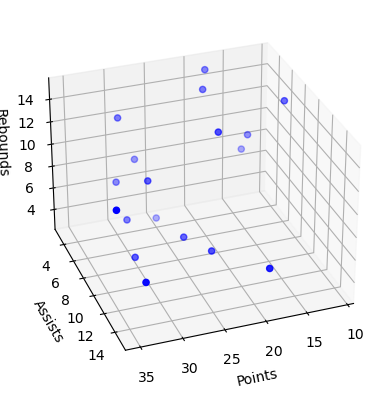

In [56]:
#1
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data['Points'],data['Assists'],data['Rebounds'], color='blue')
ax.set_xlabel('Points')
ax.set_ylabel('Assists')
ax.set_zlabel('Rebounds')
ax.view_init(elev=30, azim=70)
plt.show()

In [60]:
def euclidean_distance(point1, point2):
    return np.sqrt(np.sum((point1 - point2) ** 2))
def manhattan_distance(point1, point2):
    return np.sum(np.abs(point1 - point2))
def minkowski_distance(point1, point2, p=3):
    return np.sum(np.abs(point1 - point2) ** p) ** (1/p)

def kmeans(data, k, distance_metric='euclidean', max_iters=100):
    centroids = data.iloc[:k].values
    sse_history = []  

    for _ in range(max_iters):
        distances = np.zeros((data.shape[0], k))
        for i in range(k):
            for j in range(data.shape[0]):
                if distance_metric == 'euclidean':
                    distances[j, i] = euclidean_distance(data.iloc[j].values, centroids[i])
                elif distance_metric == 'manhattan':
                    distances[j, i] = manhattan_distance(data.iloc[j].values, centroids[i])
                elif distance_metric == 'minkowski':
                    distances[j, i] = minkowski_distance(data.iloc[j].values, centroids[i])
        labels = np.argmin(distances, axis=1)

        sse = np.sum((data.values - centroids[labels]) ** 2)
        sse_history.append(sse)

        new_centroids = np.array([data.values[labels == i].mean(axis=0) for i in range(k)])
        
        if np.all(centroids == new_centroids):
            break
        centroids = new_centroids

    return labels, centroids, sse_history



def plot_clusters(data, labels, centroids, k):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(data['Points'], data['Assists'], data['Rebounds'], c=labels, cmap='viridis', marker='o')
    
    ax.scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2], color='red', s=80, marker='X')
    
    ax.set_xlabel('Points')
    ax.set_ylabel('Assists')
    ax.set_zlabel('Rebounds')
    ax.view_init(elev=30, azim=70)
    ax.set_title(f'K-means Clustering (K={k})')
    plt.show()

def sseplot(sse_list):
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, 5), sse_list, marker='o')
    plt.title('K vs. Sum of Squared Errors (SSE)')
    plt.xlabel('Number of Clusters (K)')
    plt.ylabel('Sum of Squared Errors (SSE)')
    plt.xticks(range(1, 5))
    plt.grid()
    optimal_k = 2  
    plt.axvline(x=optimal_k, color='r', linestyle='--', label=f'Optimal K = {optimal_k}')
    plt.legend()
    plt.show()

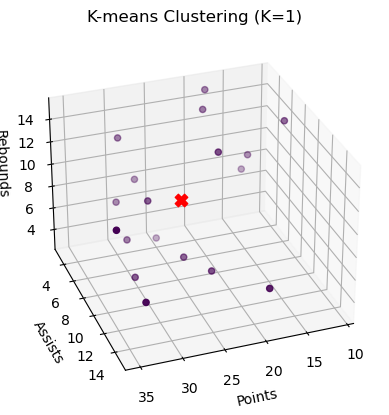

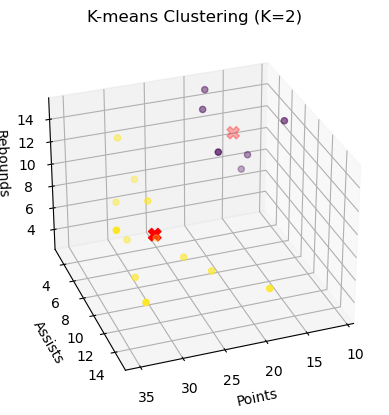

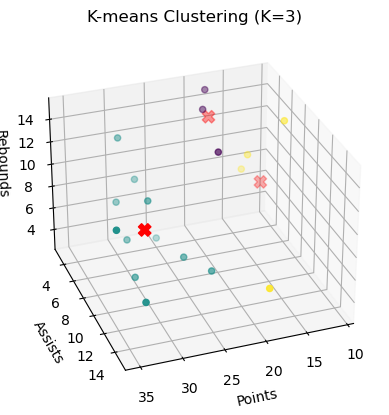

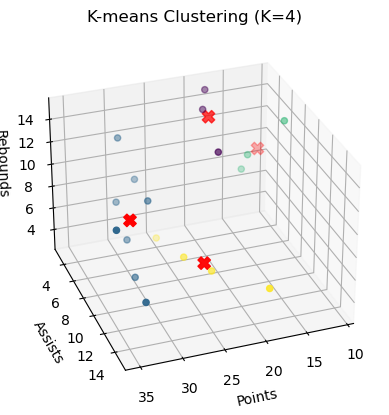

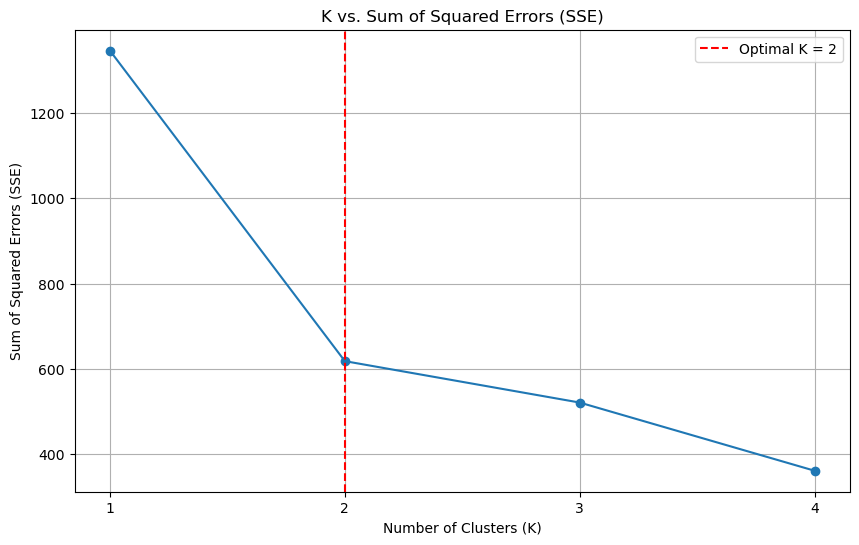

   K          SSE                                        SSE History
0  1  1345.000000                                   [3020.0, 1345.0]
1  2   618.250000              [2472.0, 774.8125, 618.2499999999999]
2  3   521.295455     [2289.0, 588.9483333333334, 521.2954545454546]
3  4   361.708333  [2270.0, 544.0697887970615, 420.27777777777777...


In [61]:
#Eucledian
sse_list = []
sse_details = []
for k in range(1, 5):
    labels, centroids, sse_history = kmeans(data, k, distance_metric='euclidean')
    sse_list.append(sse_history[-1])  
    sse_details.append(sse_history)

    plot_clusters(data, labels, centroids, k)
sseplot(sse_list)
sse_table = pd.DataFrame({
    'K': range(1, 5),
    'SSE': sse_list,
    'SSE History': sse_details
})

print(sse_table)

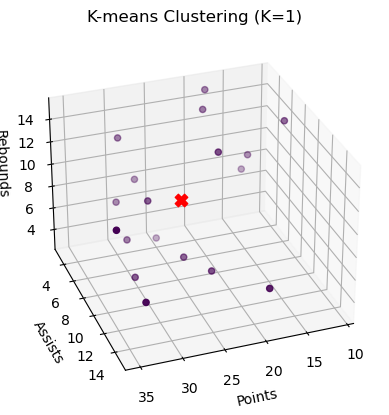

/tmp/ipykernel_5047/1840929604.py:27: RuntimeWarning: Mean of empty slice.
  new_centroids = np.array([data.values[labels == i].mean(axis=0) for i in range(k)])
/usr/lib/python3/dist-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


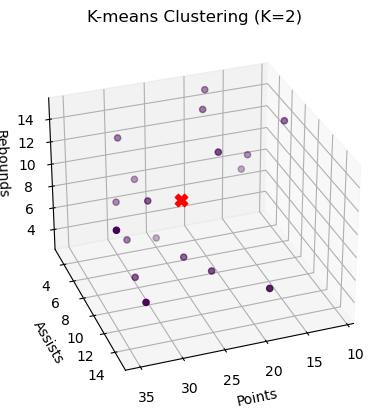

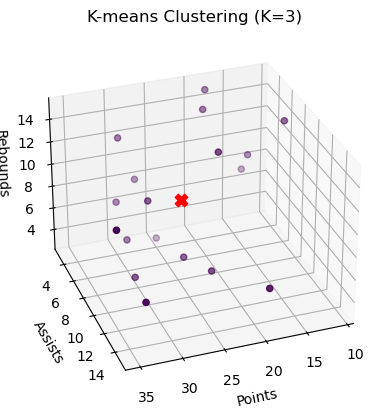

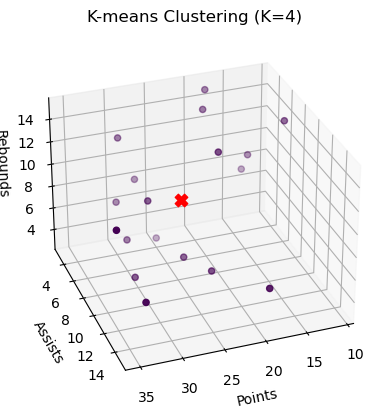

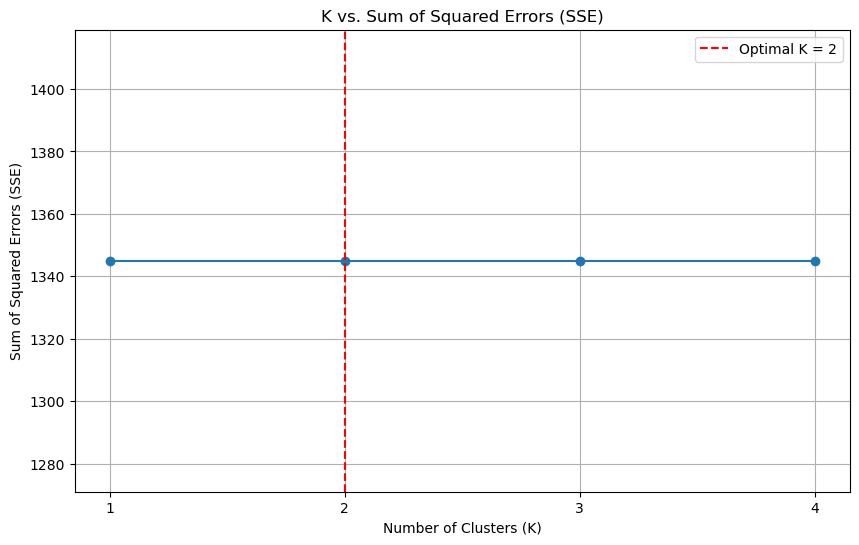

   K     SSE                                        SSE History
0  1  1345.0                                   [3020.0, 1345.0]
1  2  1345.0  [3020.0, 1345.0, 1345.0, 1345.0, 1345.0, 1345....
2  3  1345.0  [3020.0, 1345.0, 1345.0, 1345.0, 1345.0, 1345....
3  4  1345.0  [3020.0, 1345.0, 1345.0, 1345.0, 1345.0, 1345....


In [58]:
#2 Manhatten
sse_list = []
sse_details = []
for k in range(1, 5):
    labels, centroids, sse_history = kmeans(data, k, 'manhatten')
    sse_list.append(sse_history[-1])  
    sse_details.append(sse_history)

    plot_clusters(data, labels, centroids, k)
sseplot(sse_list)
sse_table = pd.DataFrame({
    'K': range(1, 5),
    'SSE': sse_list,
    'SSE History': sse_details
})

print(sse_table)

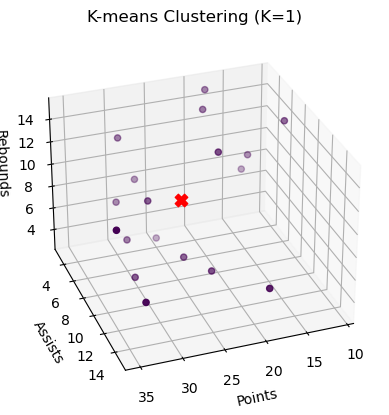

/tmp/ipykernel_5047/1840929604.py:27: RuntimeWarning: Mean of empty slice.
  new_centroids = np.array([data.values[labels == i].mean(axis=0) for i in range(k)])
/usr/lib/python3/dist-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


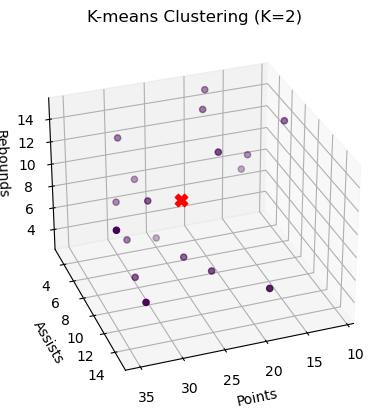

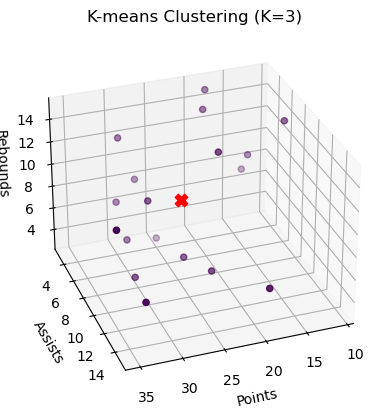

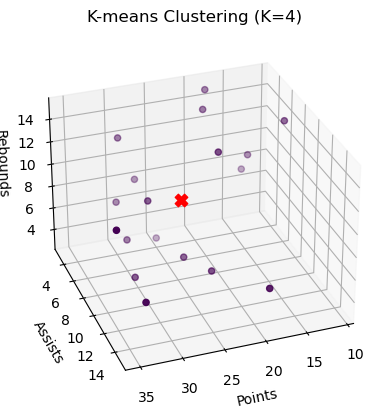

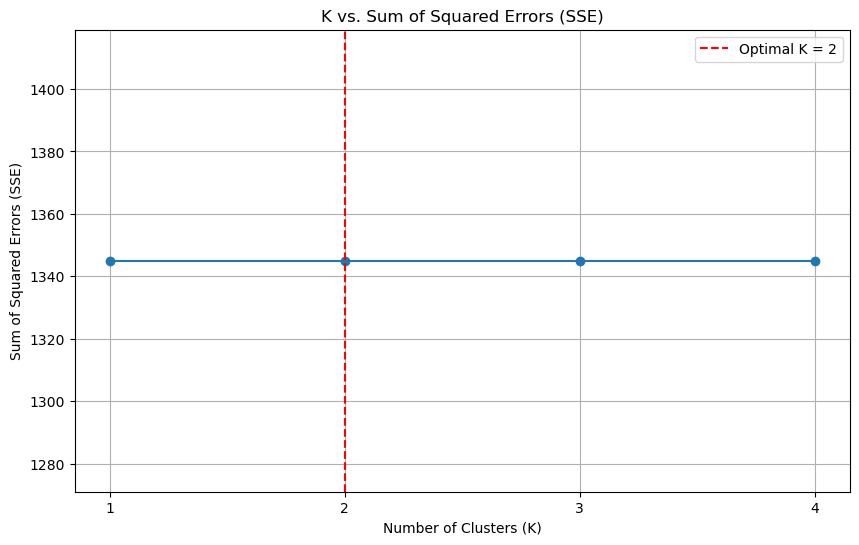

   K     SSE                                        SSE History
0  1  1345.0                                   [3020.0, 1345.0]
1  2  1345.0  [3020.0, 1345.0, 1345.0, 1345.0, 1345.0, 1345....
2  3  1345.0  [3020.0, 1345.0, 1345.0, 1345.0, 1345.0, 1345....
3  4  1345.0  [3020.0, 1345.0, 1345.0, 1345.0, 1345.0, 1345....


In [59]:
#3 Minkowski
sse_list = []
sse_details = []
for k in range(1, 5):
    labels, centroids, sse_history = kmeans(data, k, 'minkowksi')
    sse_list.append(sse_history[-1])  
    sse_details.append(sse_history)

    plot_clusters(data, labels, centroids, k)
sseplot(sse_list)
sse_table = pd.DataFrame({
    'K': range(1, 5),
    'SSE': sse_list,
    'SSE History': sse_details
})

print(sse_table)